In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

sys.path.append(str(Path("../src").resolve()))
from model import train_baseline_model, add_expected_points, save_artifacts

In [2]:
df = pd.read_csv("../data/processed/shots_model_input.csv")
print(df.shape)
df.head()

(218700, 28)


,grid_type,game_id,game_event_id,player_id,player_name,team_id,team_name,period,minutes_remaining,seconds_remaining,...,loc_y,shot_attempted_flag,shot_made_flag,game_date,htm,vtm,shot_angle,game_seconds_remaining,player_zone_fg_pct,shot_value
0,Shot Chart Detail,22300018,12,1627749,Dejounte Murray,1610612737,Atlanta Hawks,1,10,56,...,64,1,1,20231114,DET,ATL,112.109448,656,0.480938,2
1,Shot Chart Detail,22300018,16,1630552,Jalen Johnson,1610612737,Atlanta Hawks,1,10,18,...,178,1,1,20231114,DET,ATL,138.613881,618,0.384058,3
2,Shot Chart Detail,22300018,25,203992,Bogdan Bogdanović,1610612737,Atlanta Hawks,1,9,34,...,20,1,1,20231114,DET,ATL,172.455071,574,0.480769,2
3,Shot Chart Detail,22300018,28,1629631,De'Andre Hunter,1610612737,Atlanta Hawks,1,9,2,...,31,1,1,20231114,DET,ATL,97.352379,542,0.638462,2
4,Shot Chart Detail,22300018,32,1627749,Dejounte Murray,1610612737,Atlanta Hawks,1,8,33,...,6,1,1,20231114,DET,ATL,12.094757,513,0.581169,2


In [3]:
artifacts = train_baseline_model(df)
print("Features used:", artifacts.feature_columns)
print("\nMetrics:")
for metric, value in artifacts.metrics.items():
    print(f"  {metric}: {value:.4f}")

Features used: ['shot_distance', 'shot_angle', 'period', 'game_seconds_remaining', 'player_zone_fg_pct']

Metrics:
  roc_auc: 0.6637
  log_loss: 0.6471
  brier_score: 0.2279


In [4]:
print(f"""
ROC AUC:     {artifacts.metrics['roc_auc']:.4f}  (random = 0.50, perfect = 1.00)
Log-Loss:    {artifacts.metrics['log_loss']:.4f}  (lower is better)
Brier Score: {artifacts.metrics['brier_score']:.4f}  (lower is better, 0.25 = random)
""")


ROC AUC:     0.6637  (random = 0.50, perfect = 1.00)
Log-Loss:    0.6471  (lower is better)
Brier Score: 0.2279  (lower is better, 0.25 = random)



In [5]:
df_scored = add_expected_points(
    df,
    pipeline=artifacts.pipeline,
    feature_columns=artifacts.feature_columns,
    shot_value_column="shot_value",
)

print(df_scored[["shot_distance", "shot_value", "make_probability", "xpts"]].head(10))

   shot_distance  shot_value  make_probability      xpts
0      69.079664           2          0.496020  0.992041
1     269.235956           3          0.381633  1.144900
2     152.318745           2          0.482224  0.964448
3      31.256999           2          0.654354  1.308708
4      28.635642           2          0.605915  1.211830
5      22.561028           2          0.662853  1.325706
6      40.249224           2          0.459117  0.918233
7      67.542579           2          0.464359  0.928718
8      30.463092           2          0.617716  1.235431
9      18.681542           2          0.615593  1.231185


In [6]:
df_scored["xpts"].describe()

count    218700.000000
mean          1.091078
std           0.247875
min           0.204513
25%           0.911878
50%           1.083636
75%           1.275214
max           2.694717
Name: xpts, dtype: float64

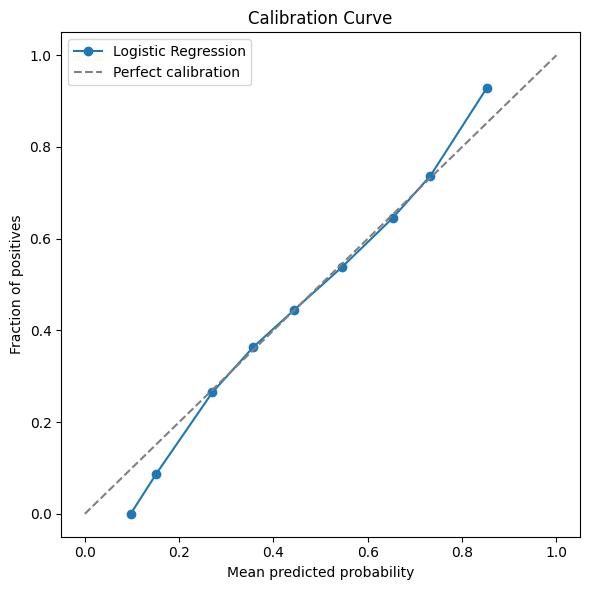

In [7]:
y_true = df_scored["shot_made_flag"]
y_prob = df_scored["make_probability"]

fraction_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot(mean_pred, fraction_pos, marker="o", label="Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
top_shots = df_scored.nlargest(10, "xpts")[
    ["player_name", "shot_zone_basic", "shot_distance", "shot_value", "make_probability", "xpts"]
]
top_shots

,player_name,shot_zone_basic,shot_distance,shot_value,make_probability,xpts
203265,Marvin Bagley III,Left Corner 3,240.052078,3,0.898239,2.694717
86183,Orlando Robinson,Left Corner 3,245.130577,3,0.895493,2.686478
81637,Dru Smith,Left Corner 3,240.208243,3,0.894616,2.683847
25626,Zion Williamson,Right Corner 3,229.176788,3,0.892615,2.677846
81196,Orlando Robinson,Right Corner 3,223.008968,3,0.892429,2.677288
141074,Drew Eubanks,Left Corner 3,229.706334,3,0.891418,2.674254
105766,Harry Giles III,Left Corner 3,232.077573,3,0.891272,2.673816
150945,Ashton Hagans,Right Corner 3,231.812424,3,0.889741,2.669223
59145,Jock Landale,Right Corner 3,246.018292,3,0.889260,2.667779
21935,Pete Nance,Above the Break 3,262.908729,3,0.888987,2.666960


In [9]:
player_summary = (
    df_scored.groupby("player_name")
    .agg(
        attempts=("xpts", "count"),
        avg_xpts=("xpts", "mean"),
        avg_make_prob=("make_probability", "mean"),
        actual_fg_pct=("shot_made_flag", "mean"),
    )
    .query("attempts >= 100")
    .sort_values("avg_xpts", ascending=False)
    .head(20)
)
player_summary

,attempts,avg_xpts,avg_make_prob,actual_fg_pct
player_name,,,,
Dereck Lively II,296,1.467804,0.733532,0.746622
Daniel Gafford,480,1.431751,0.715875,0.725000
Jaxson Hayes,175,1.426593,0.710908,0.720000
Luke Kornet,203,1.398188,0.696910,0.699507
Trayce Jackson-Davis,332,1.389762,0.694726,0.701807
Nick Richards,376,1.377419,0.688564,0.691489
Dwight Powell,106,1.368443,0.679005,0.679245
Bol Bol,151,1.344856,0.600113,0.615894
Jalen Smith,395,1.330861,0.589060,0.592405


In [10]:
artifact_path = save_artifacts(artifacts, "../models/baseline_logistic.joblib")
print(f"Model saved to {artifact_path}")

Model saved to ..\models\baseline_logistic.joblib


In [11]:
scored_path = Path("../data/processed/shots_model_input.csv")
df_scored.to_csv(scored_path, index=False)
print(f"Scored dataset saved with {len(df_scored):,} rows")

Scored dataset saved with 218,700 rows
